## Connect to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Install Libraries

In [ ]:
!pip install numpy==1.26.4 ultralytics mediapipe==0.10.11
# opencv-python scikit-learn matplotlib xgboost mediapipe


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

## Importing Libraries

In [ ]:
# Import necessary libraries for the project

import matplotlib.pyplot as plt  # For plotting and visualization
import cv2  # OpenCV for image and video processing
import os  # For interacting with the operating system (file paths, directories)
import numpy as np  # For numerical operations and array handling
from ultralytics import YOLO  # For YOLO pose estimation model
import mediapipe as mp  # For MediaPipe pose estimation models
from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.preprocessing import MinMaxScaler, LabelEncoder  # For feature scaling and label encoding
from sklearn.linear_model import LogisticRegression  # Logistic Regression classifier
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from xgboost import XGBClassifier  # XGBoost classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix  # Evaluation metrics
import seaborn as sns  # For advanced data visualization (heatmaps, etc.)
import pandas as pd  # For data manipulation and analysis
import joblib  # For saving and loading models and preprocessing objects
from collections import Counter  # For counting occurrences of elements (e.g., predictions)
import shutil  # For high-level file operations (copying, removing directories)
from IPython.display import display, Image  # Import display and Image from IPython.display for displaying images in the notebook.


In [ ]:
# Video Prediction Path
video_path = '/content/drive/MyDrive/Data/Dancing/2-#jennielikejennie #jennie #likejennie #dancecove7493853985120505094.mp4'


# Object Detection

In [ ]:
!pip install roboflow==1.1.48 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.1 MB/s eta 0:00:00


In [ ]:
import os # Get the current working directory
HOME = os.getcwd() # Get the current working directory
print(HOME) # Print the current working directory


/content


In [ ]:
from IPython import display  # Import the display module from IPython for clearing outputs and displaying images.
display.clear_output()  # Clear the current output in the Jupyter Notebook cell.

import ultralytics  # Import the ultralytics library, which is used for YOLO model training and inference.
ultralytics.checks()  # Run checks to ensure the ultralytics library and its dependencies are properly installed.

from ultralytics import YOLO  # Import the YOLO class from the ultralytics library for model creation and usage.
from IPython.display import display, Image  # Import display and Image from IPython.display for displaying images in the notebook.


Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.7/112.6 GB disk)


In [ ]:
!mkdir -p {HOME}/datasets  # Create a directory named 'datasets' inside the current working directory if it doesn't already exist.
%cd {HOME}/datasets  # Change the current working directory to the newly created 'datasets' directory.

from roboflow import Roboflow  # Import the Roboflow class from the roboflow library.

rf = Roboflow(api_key="UGmDlp3rOig59tfYSH9m")  # Initialize the Roboflow object with the provided API key.

project = rf.workspace("alexa-fiverr").project("alexa-tybnf")  # Access the specific project within the specified workspace.

dataset = project.version(1).download("yolov8")  # Download version 3 of the dataset in YOLOv8 format.


[Errno 2] No such file or directory: '/content/datasets # Change the current working directory to the newly created datasets directory.'
/content
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Alexa-1 in yolov8:: 100%|██████████| 6522/6522 [00:03<00:00, 1727.95it/s]


In [ ]:
%cd {HOME}  # Change the current working directory to the value stored in the HOME variable.

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=5 imgsz=800 plots=True
# Run the YOLO command-line interface to train a detection model:
# - task=detect: Specifies the task as object detection.
# - mode=train: Sets the mode to training.
# - model=yolov8s.pt: Specifies the pre-trained YOLOv8s model to use as a starting point.
# - data={dataset.location}/data.yaml: Specifies the path to the dataset configuration file.
# - epochs=5: Sets the number of training epochs to 5.
# - imgsz=800: Sets the image size for training to 800x800 pixels.
# - plots=True: Enables the generation of training plots.


[Errno 2] No such file or directory: '/content # Change the current working directory to the value stored in the HOME variable.'
/content
100% 21.5M/21.5M [00:00<00:00, 337MB/s]
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Alexa-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, mu

[Errno 2] No such file or directory: '/content # Change the current working directory to the value stored in the HOME variable.'
/content


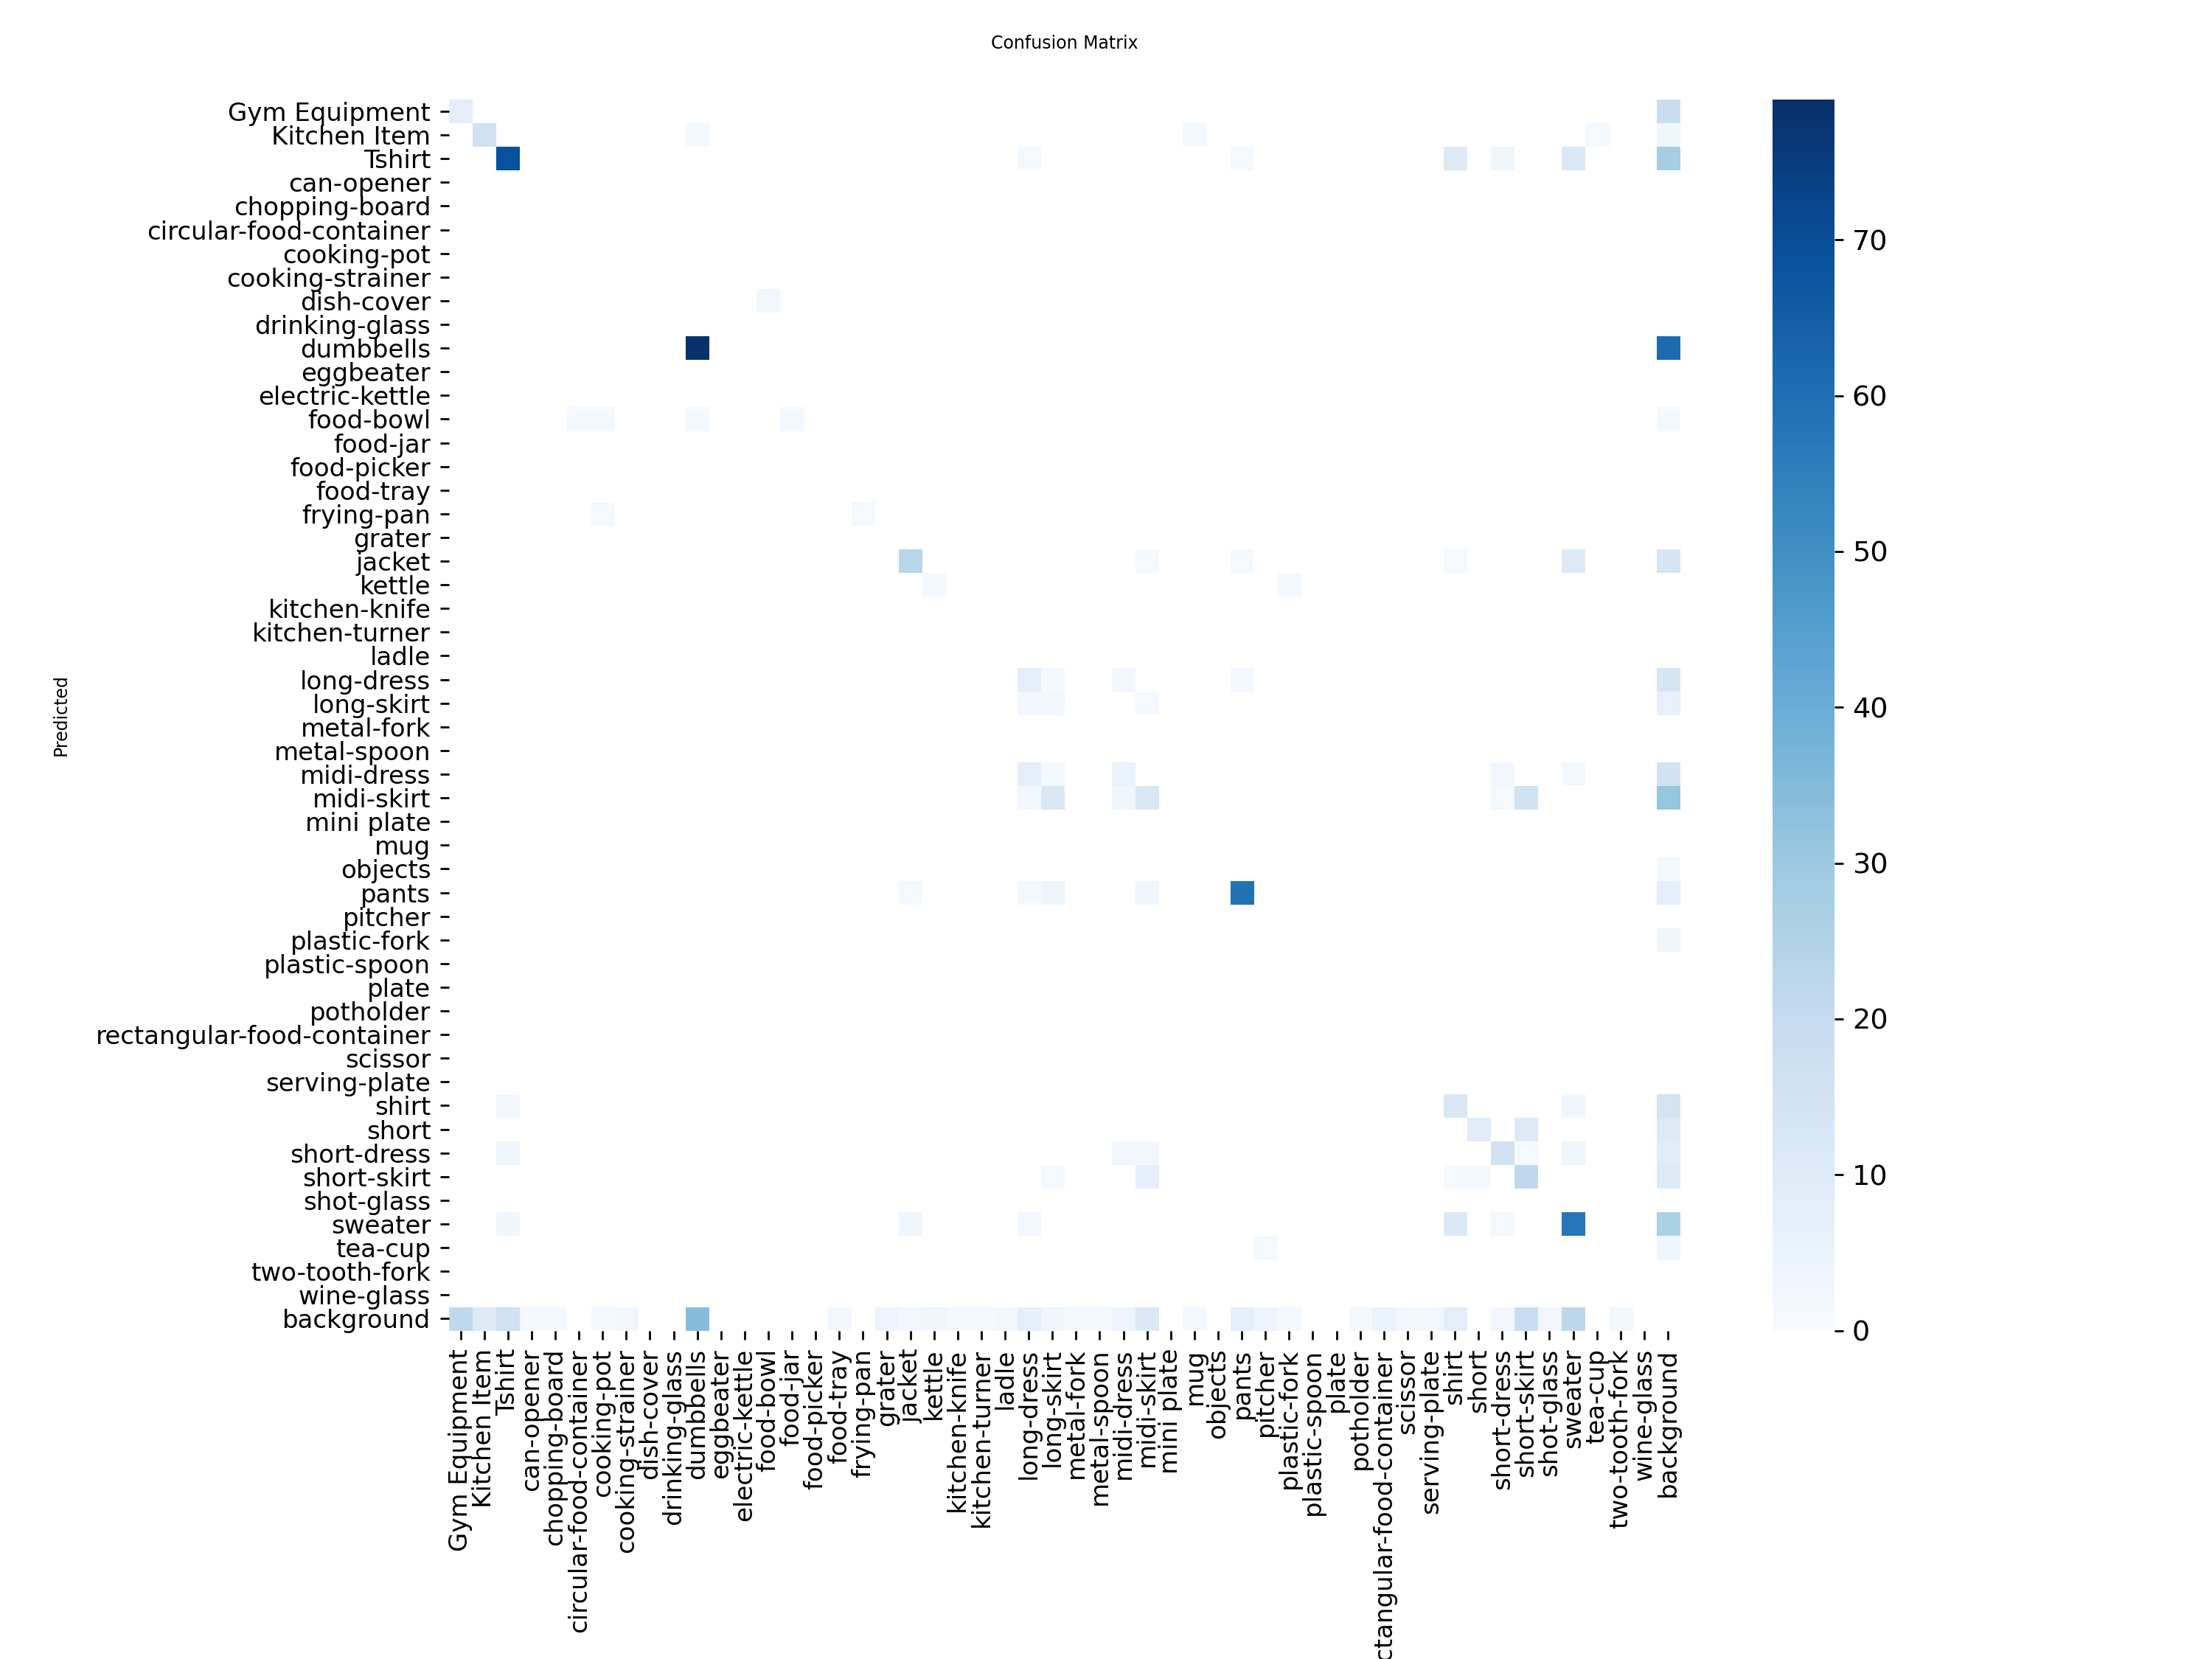

In [ ]:
%cd {HOME}  # Change the current working directory to the value stored in the HOME variable.
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)  # Display the confusion matrix image from the specified path with a width of 600 pixels.


/content


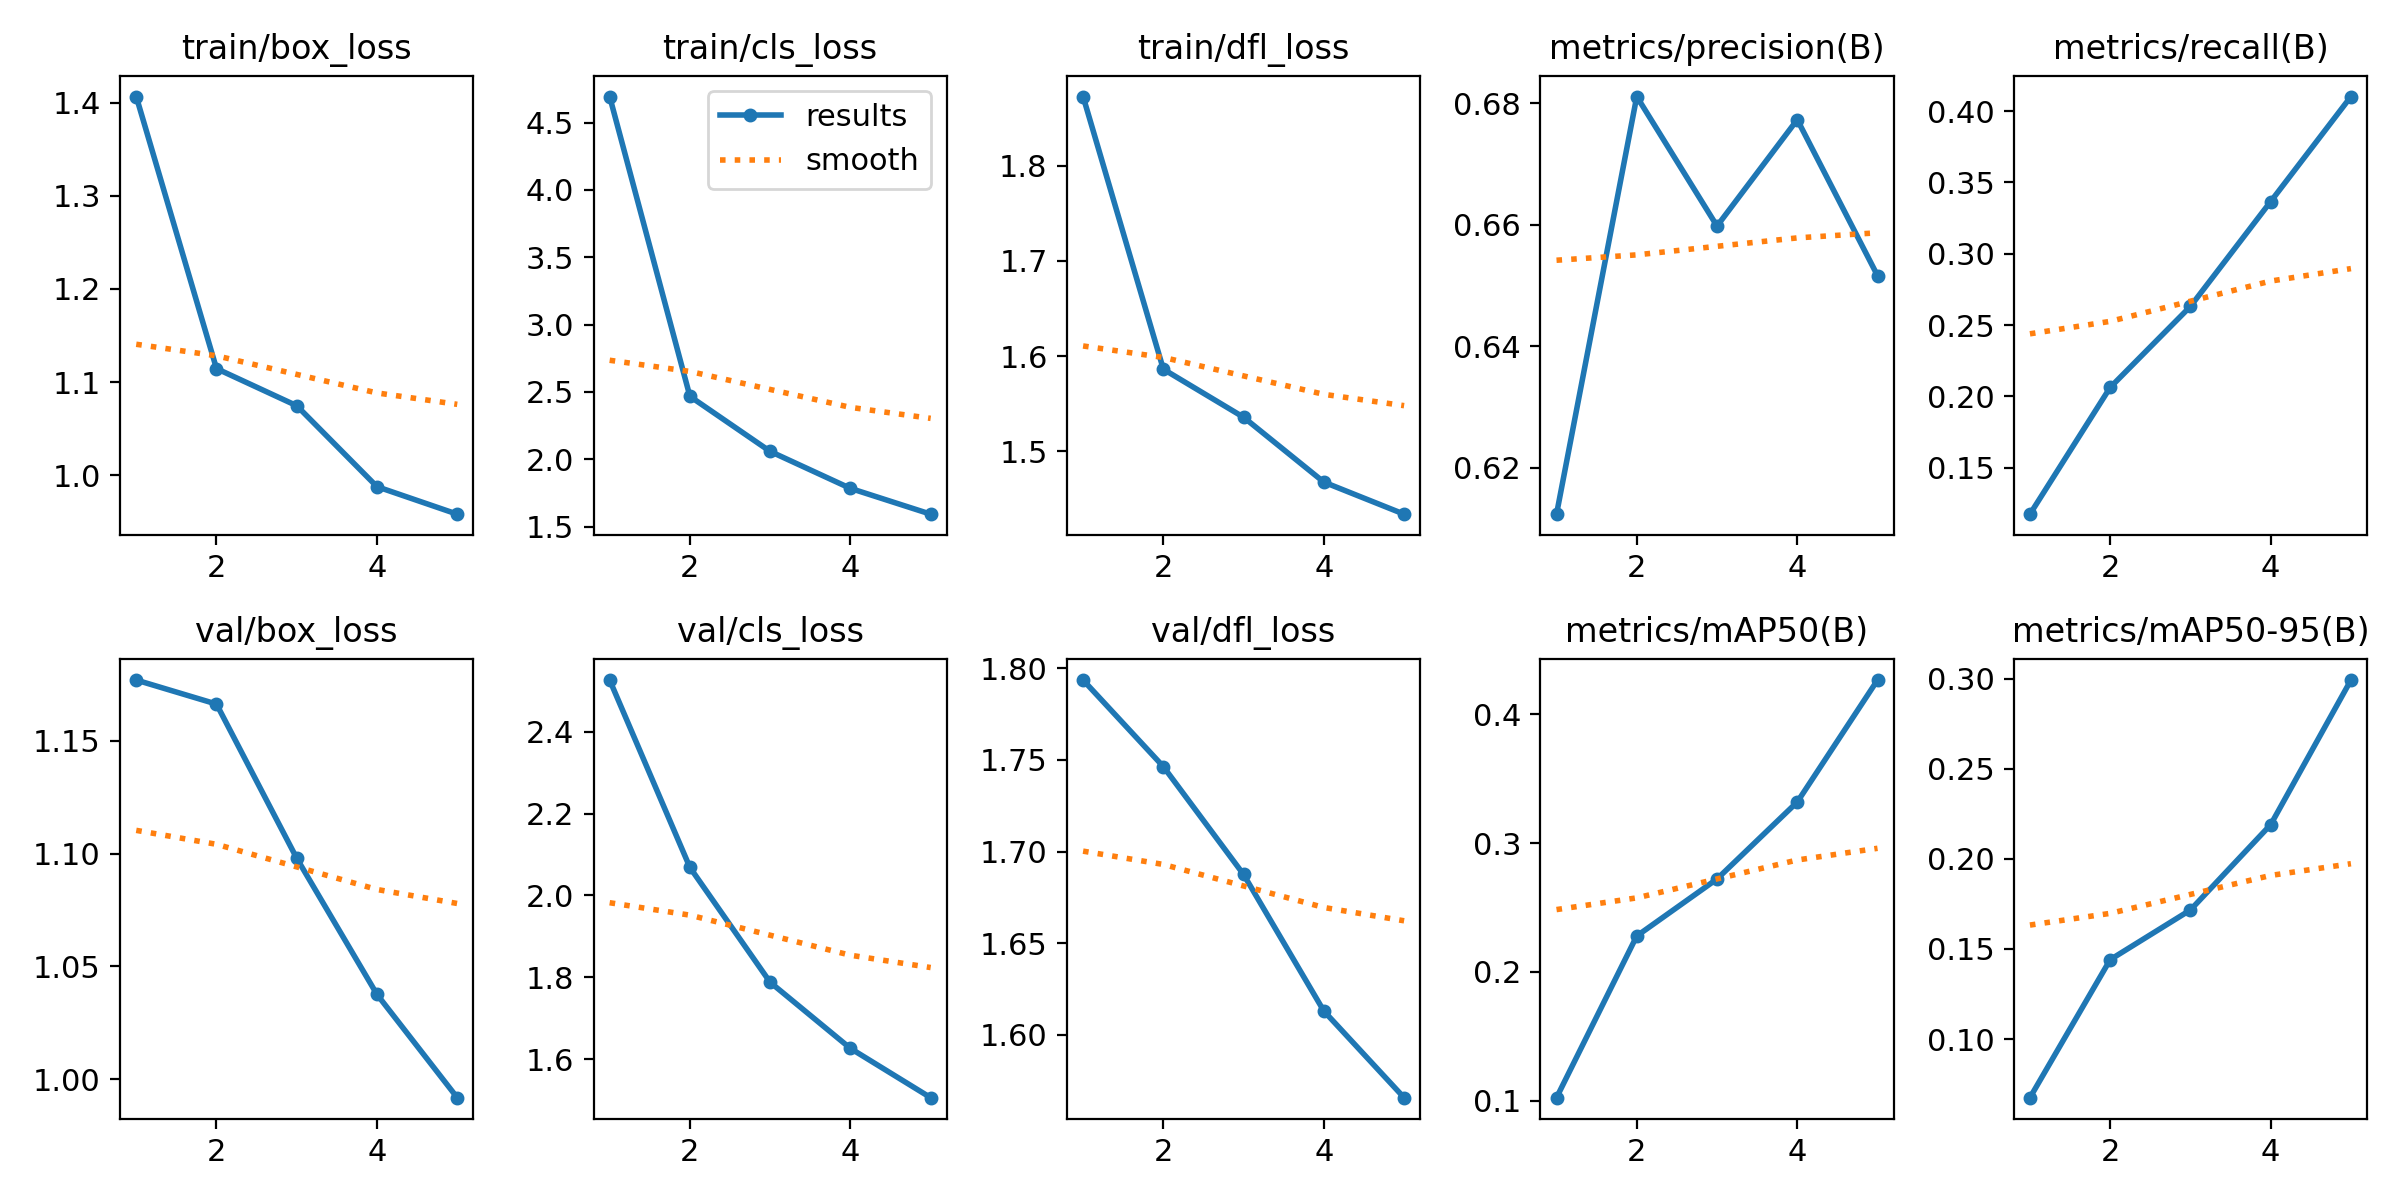

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)


/content


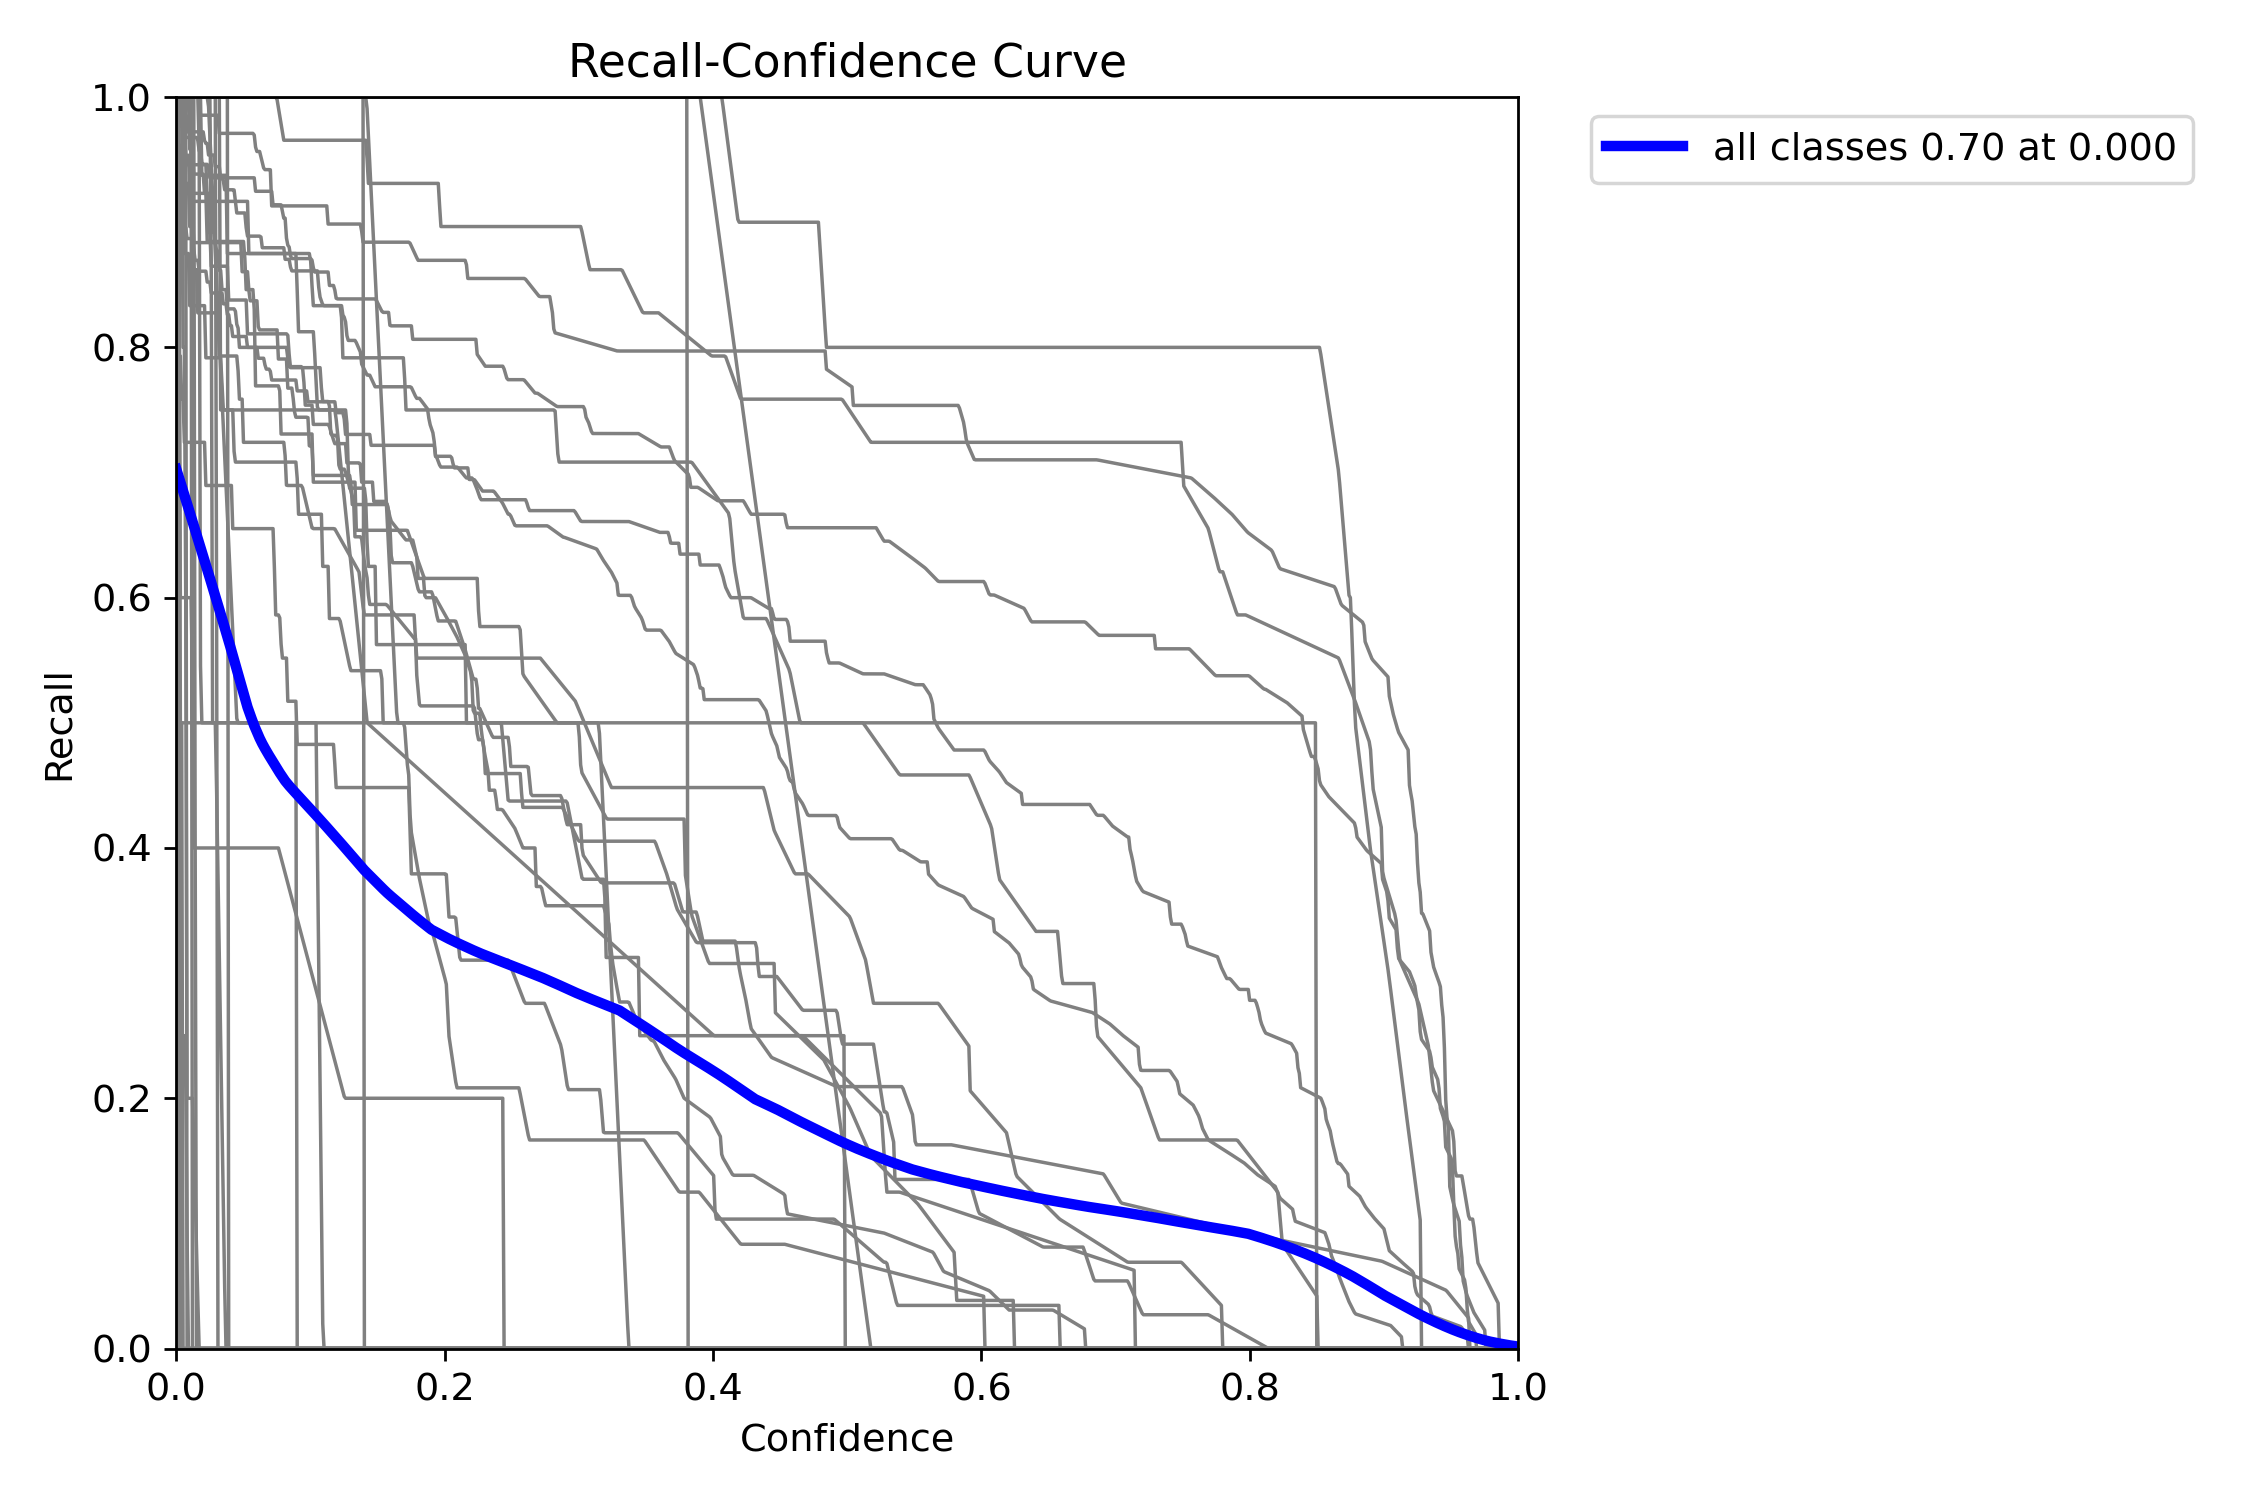

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/R_curve.png', width=600)


/content


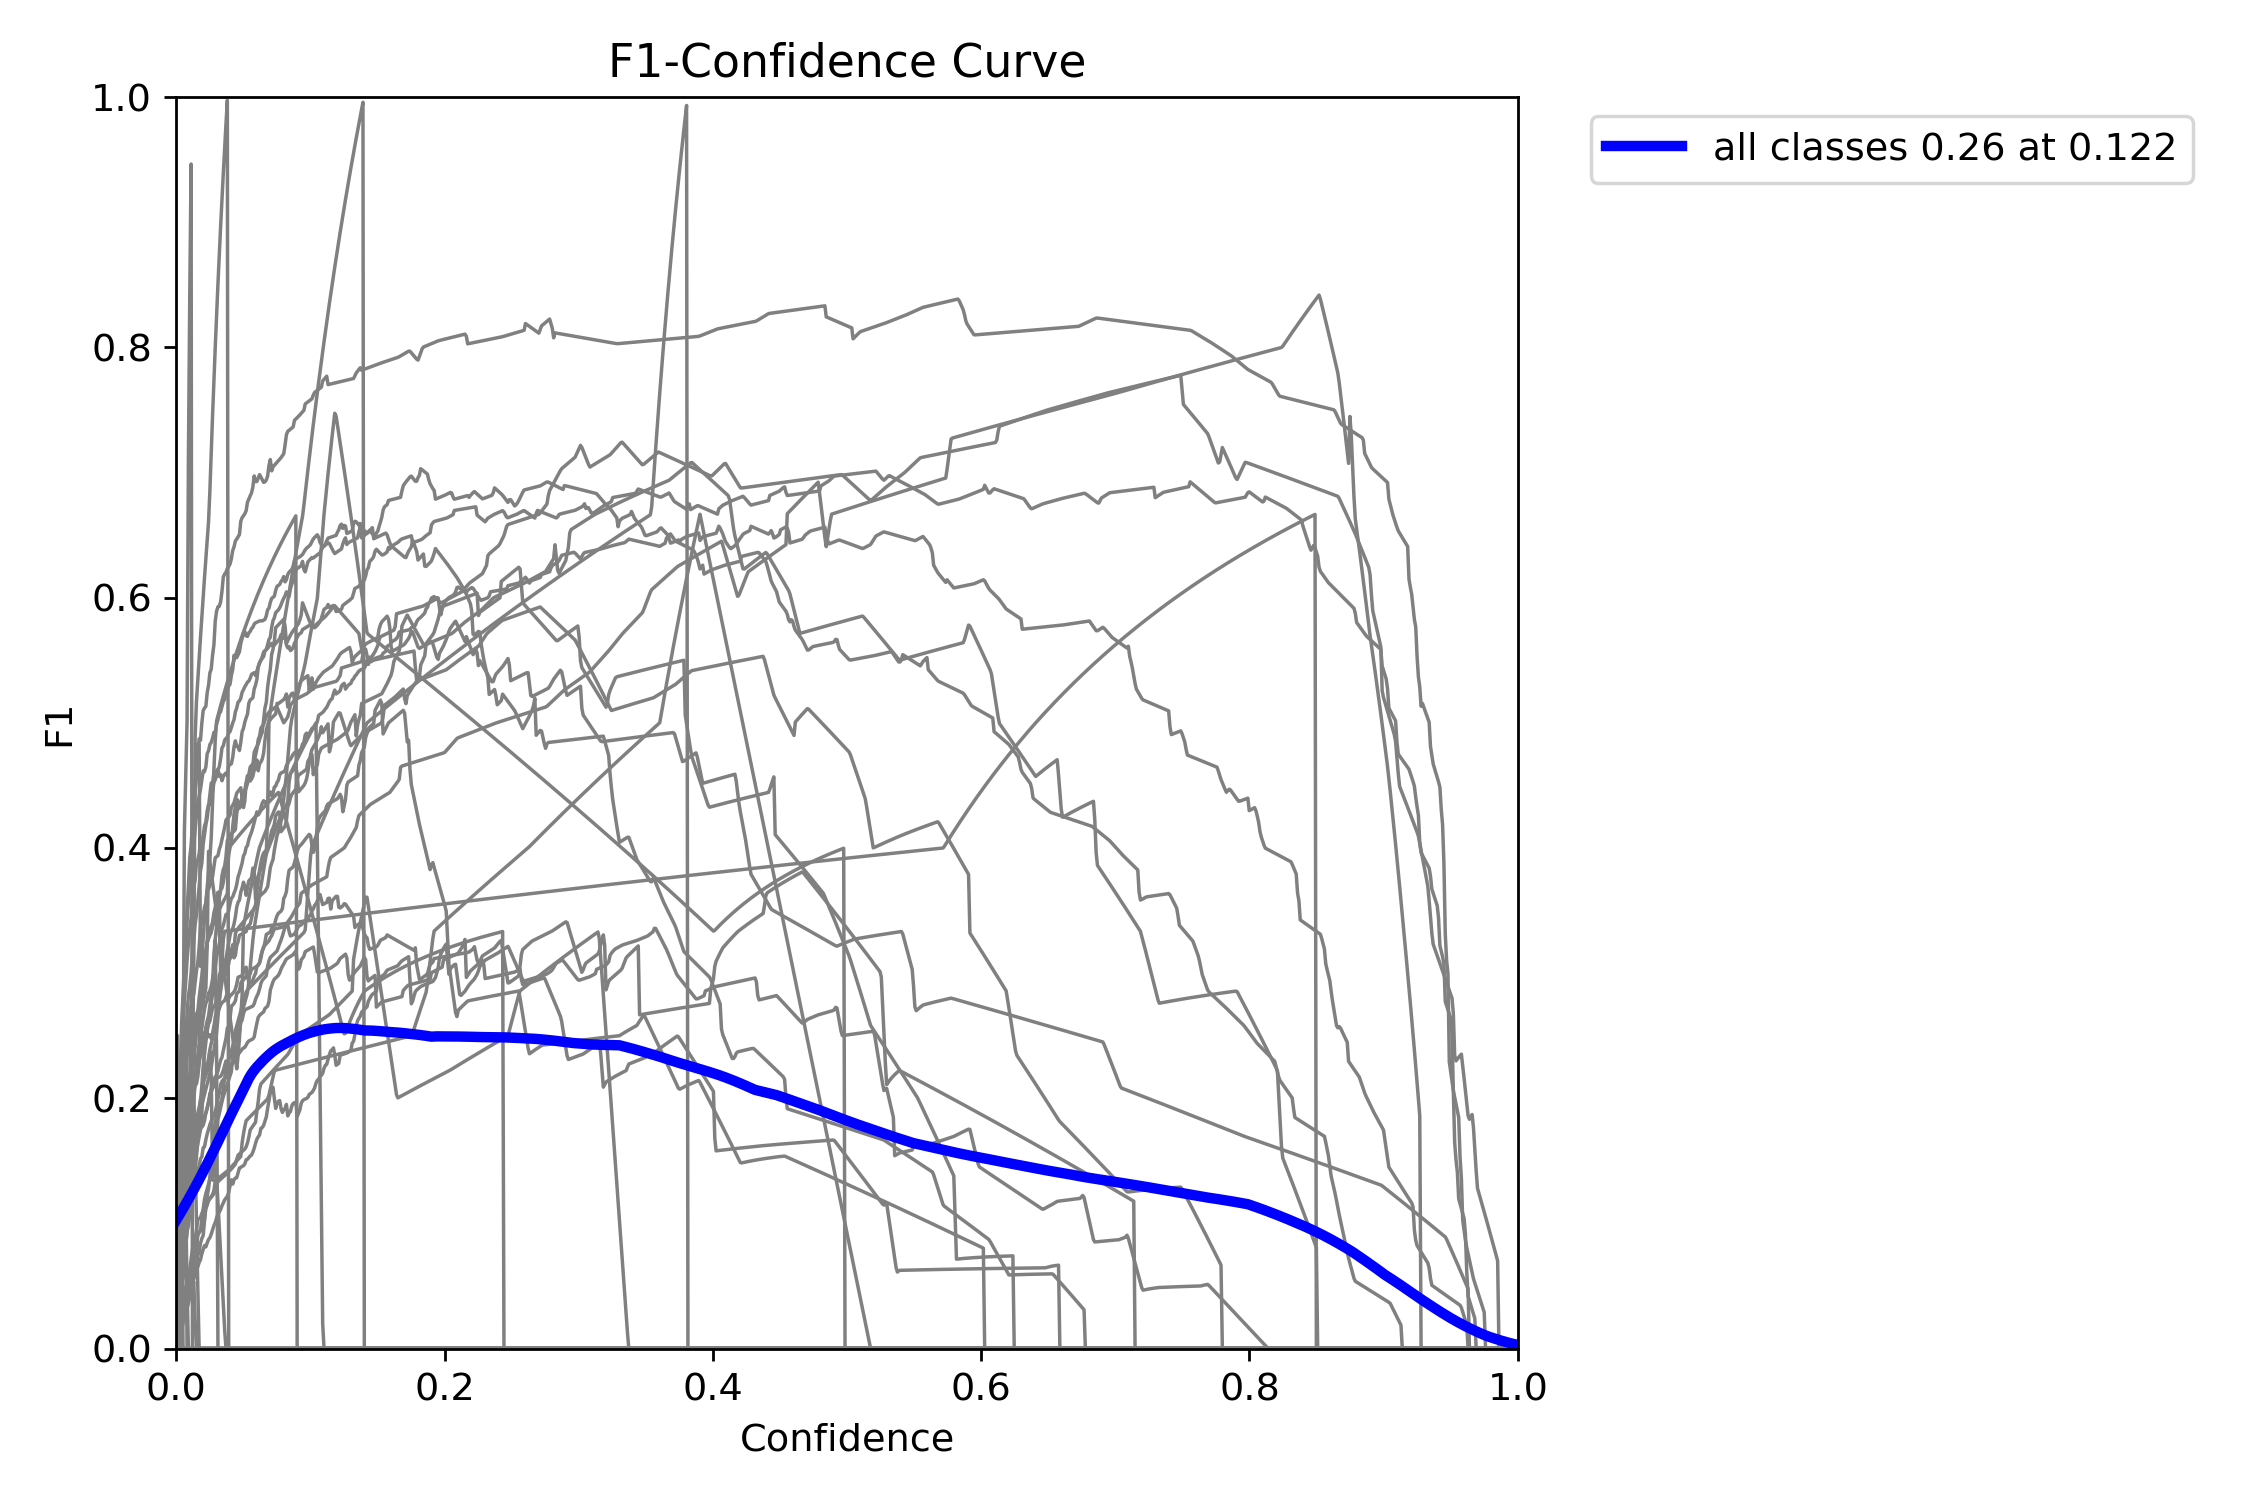

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/F1_curve.png', width=600)


/content


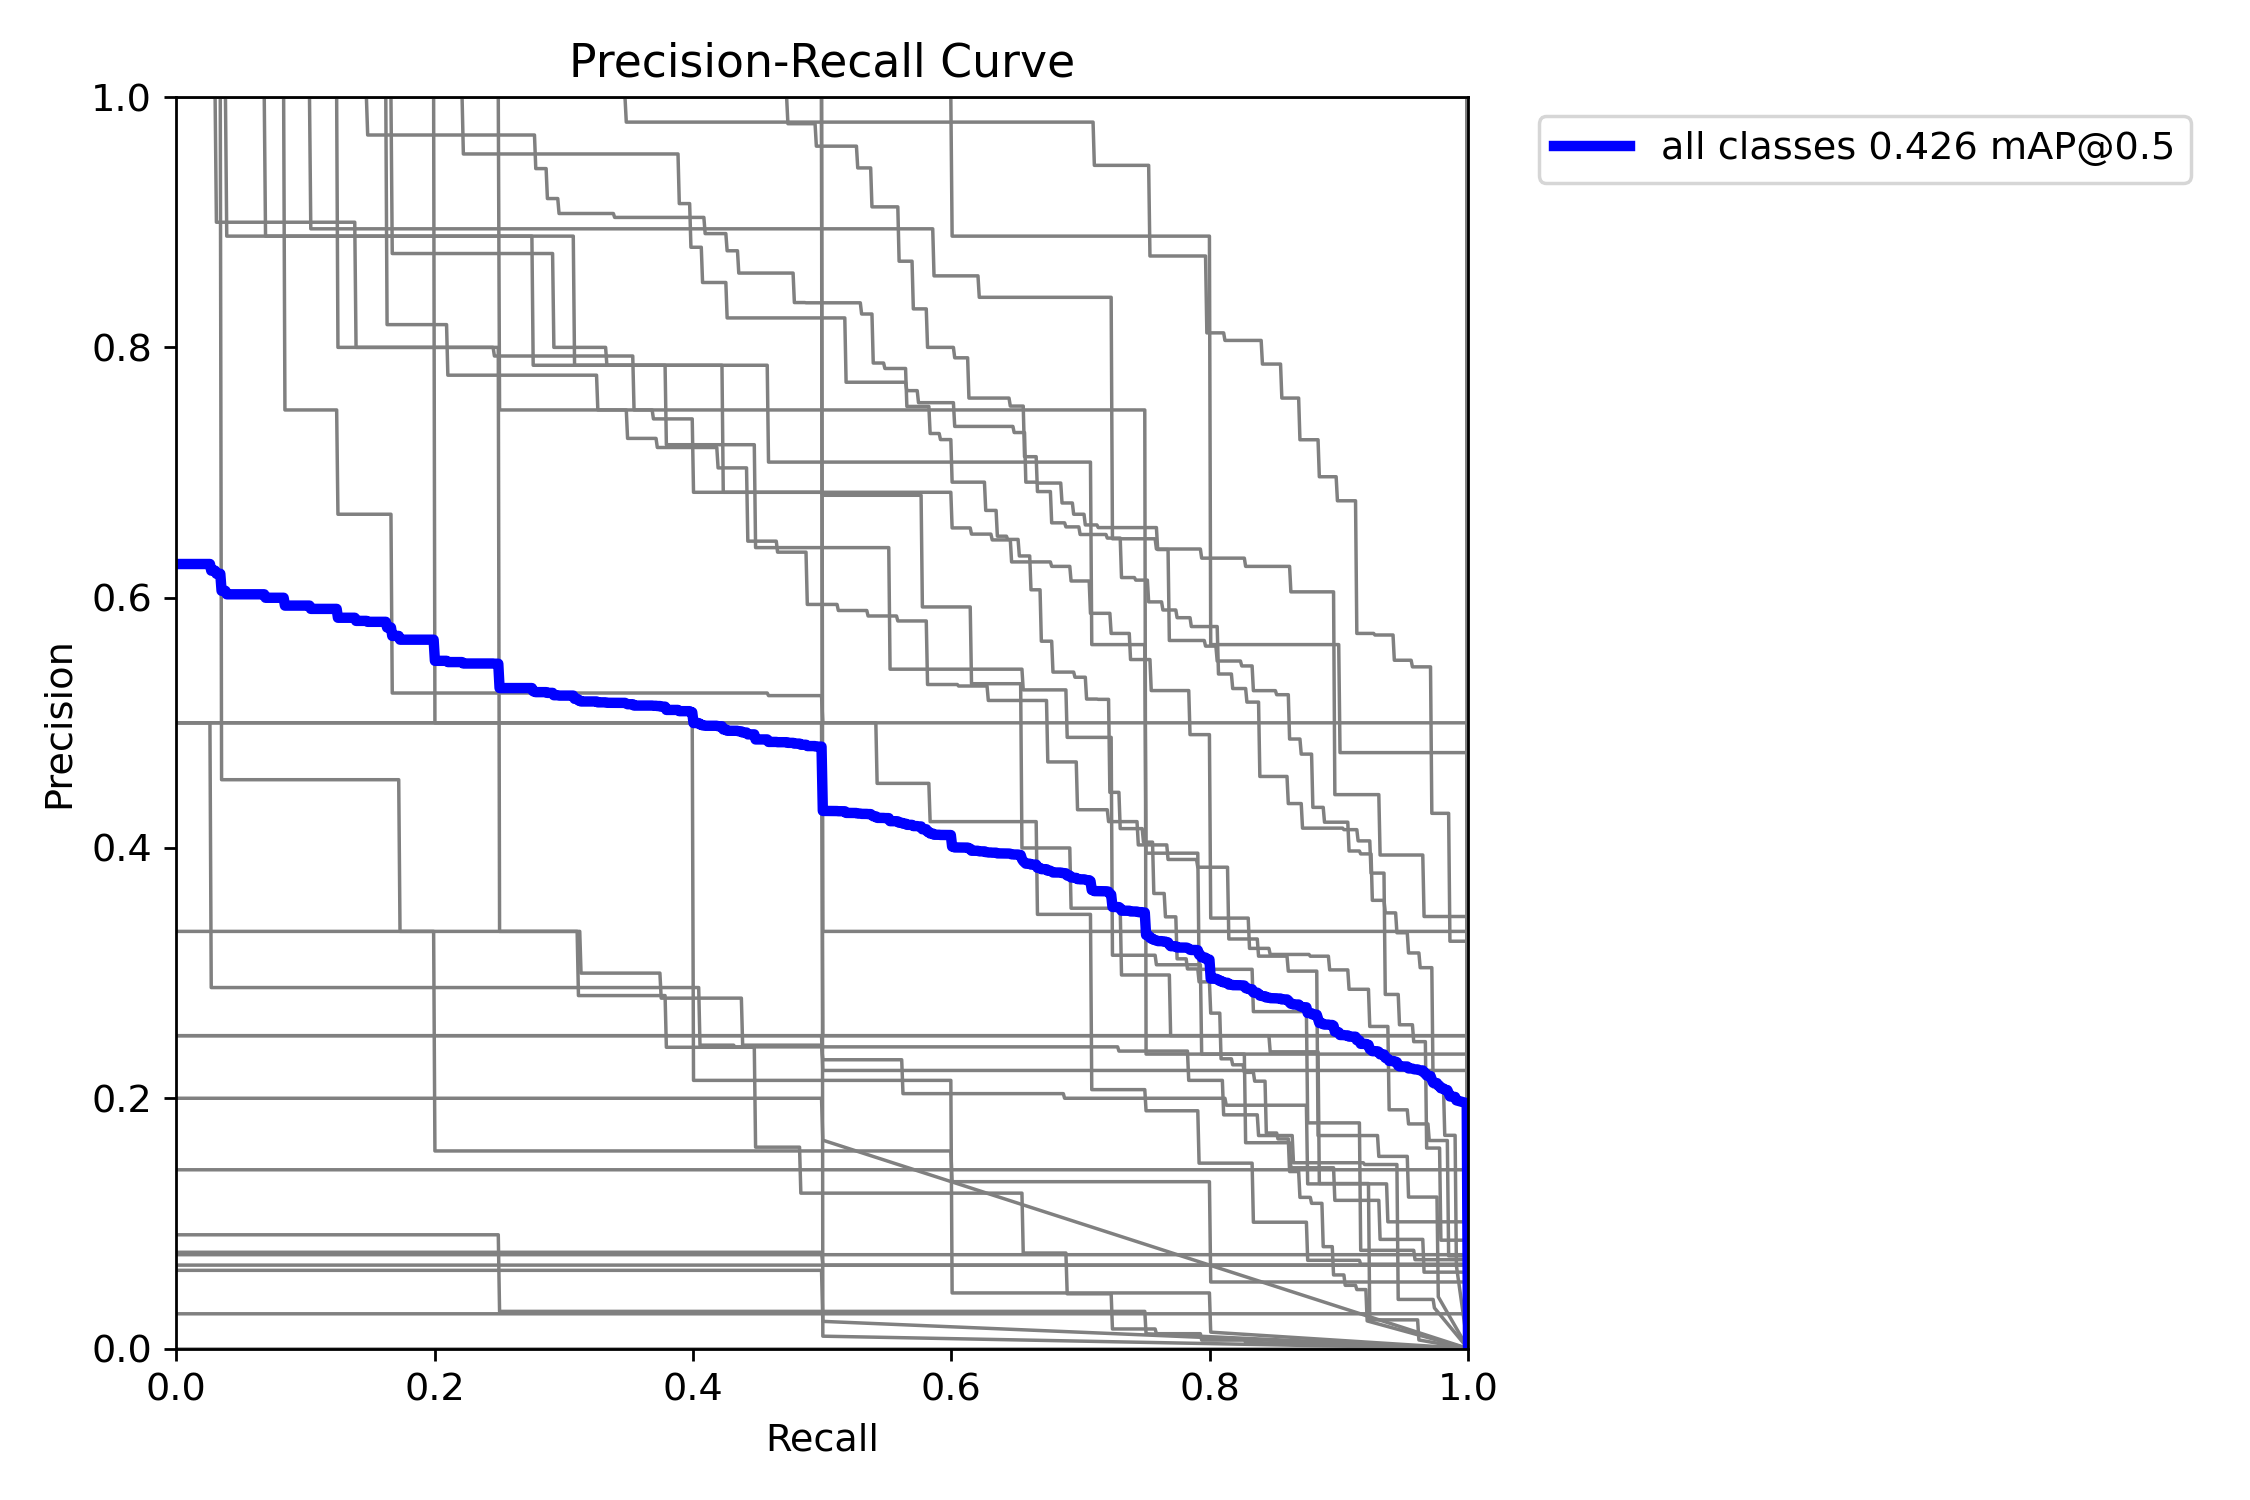

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/PR_curve.png', width=600)


/content


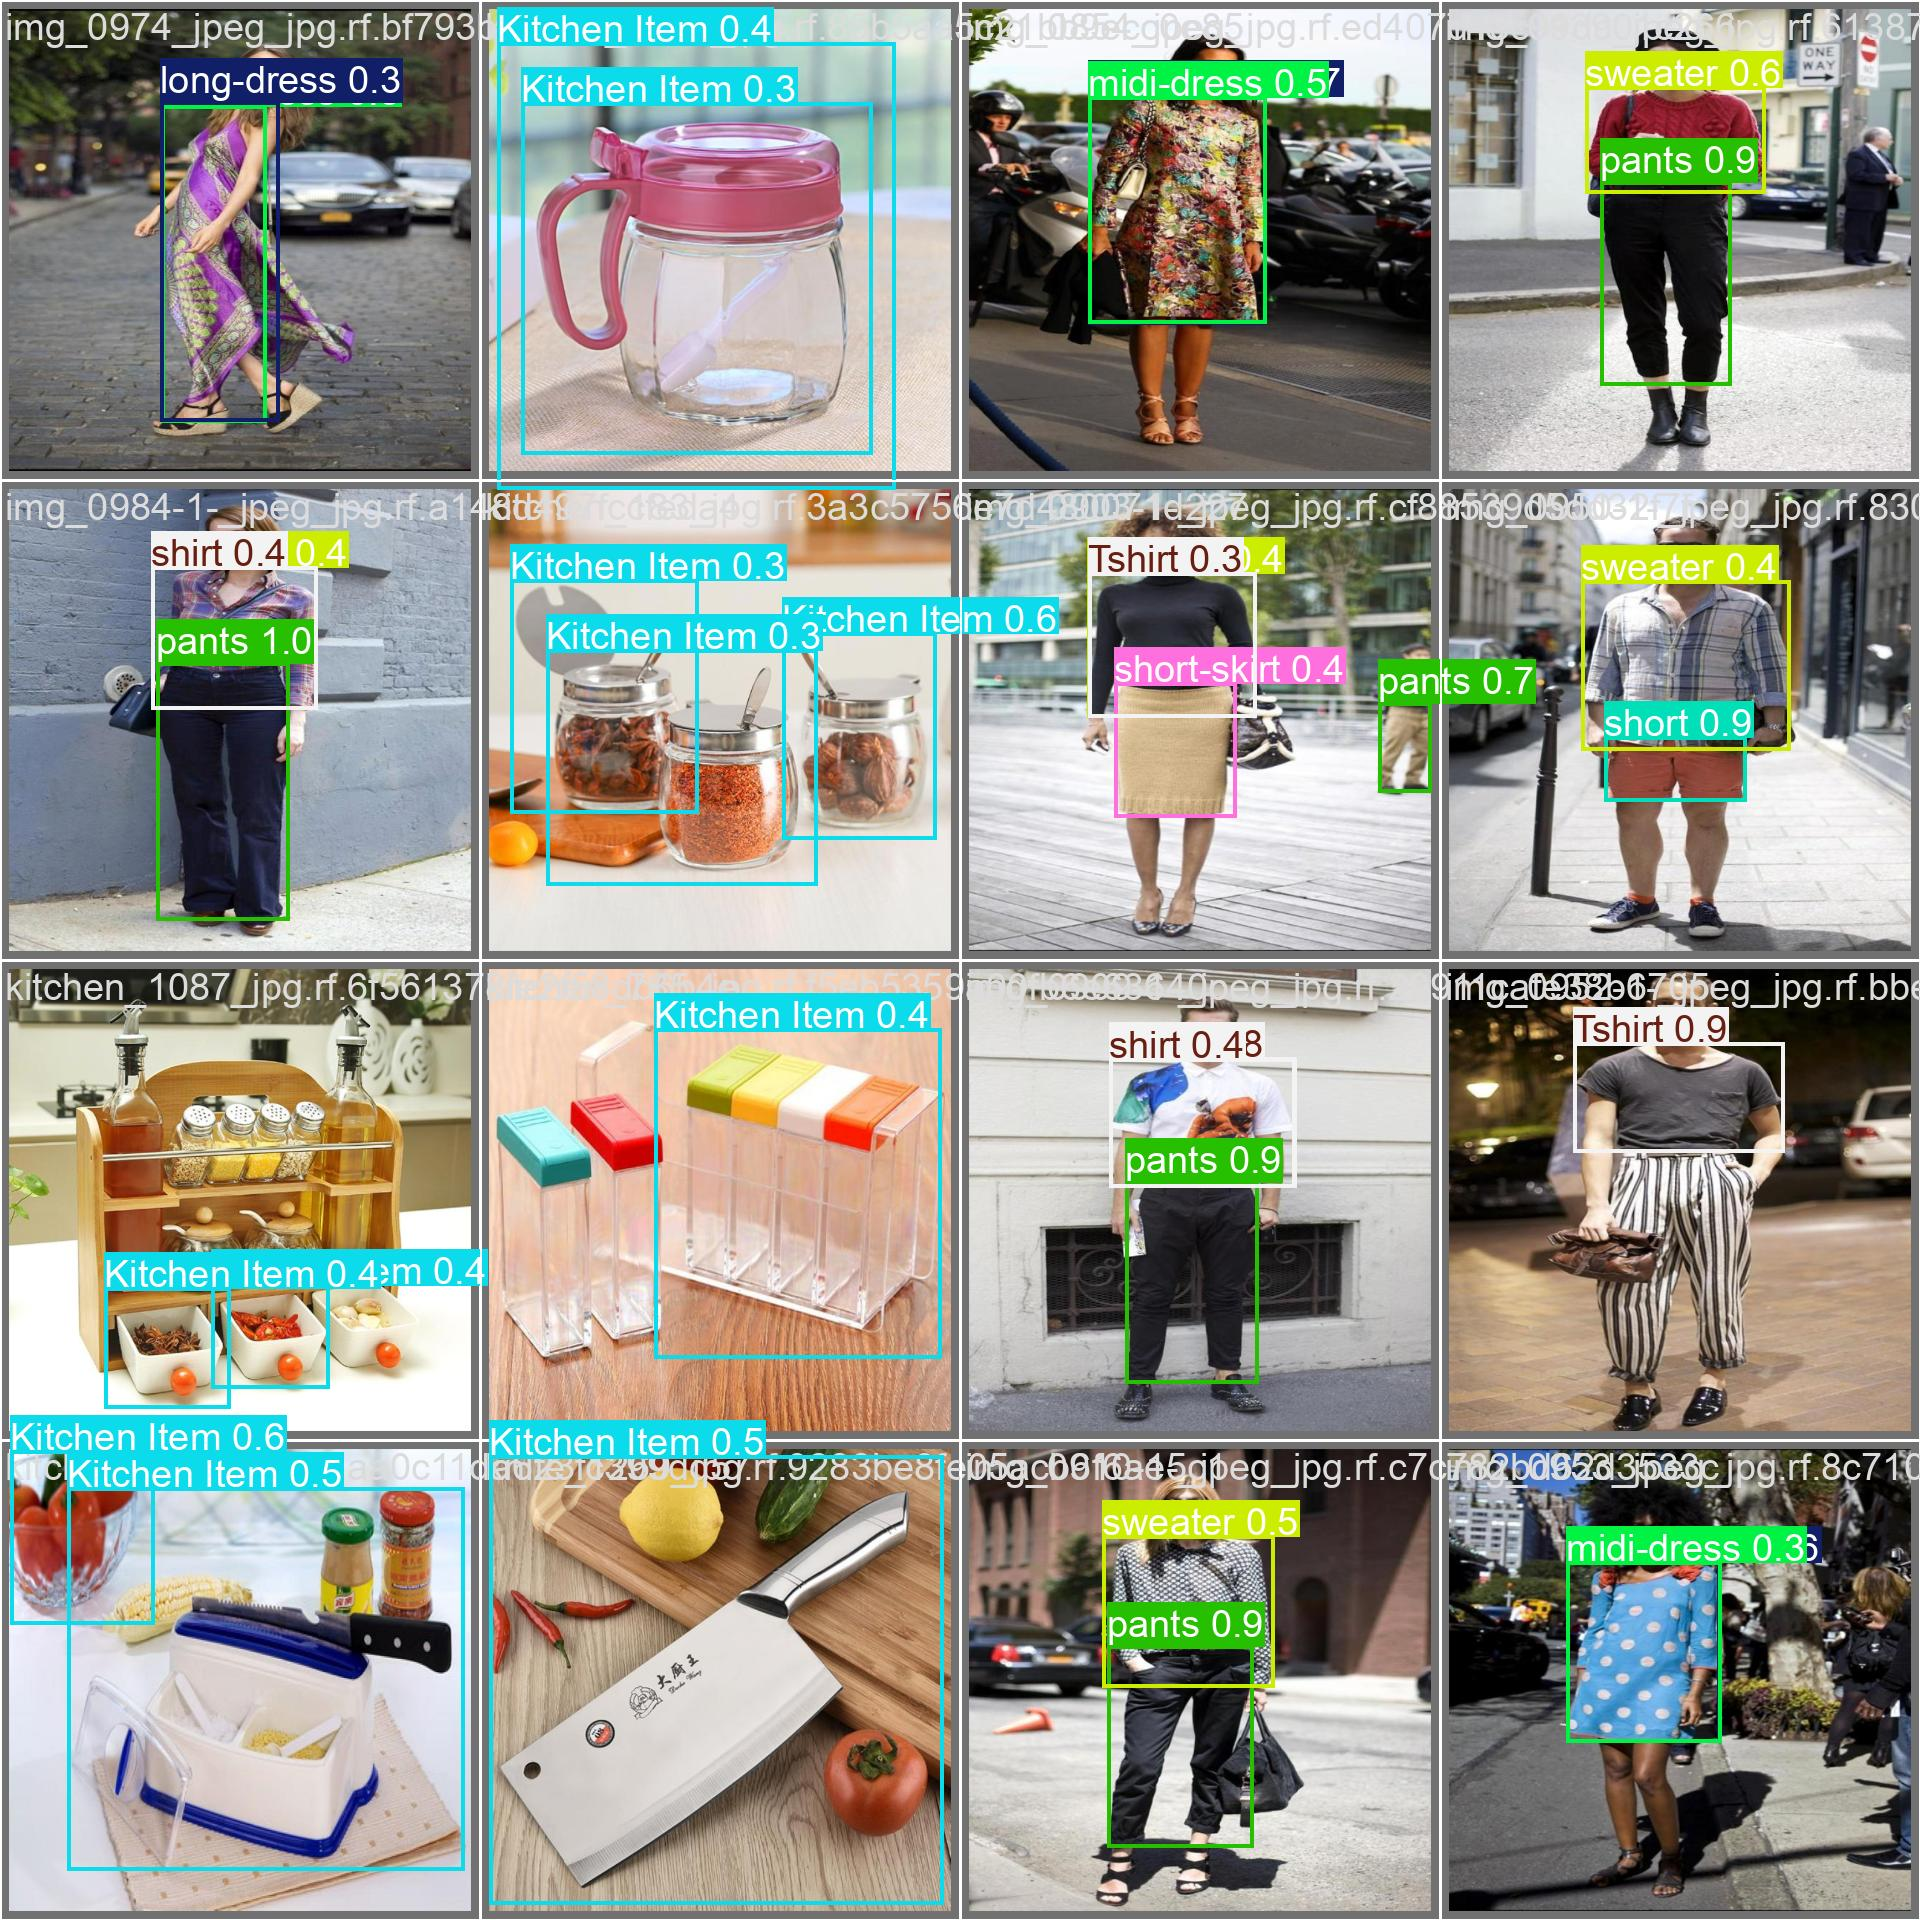

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)


In [ ]:
from ultralytics import YOLO  # Import the YOLO class from the ultralytics library for model creation and inference.
import os  # Import the os module for interacting with the operating system.

model = YOLO("/content/runs/detect/train/weights/best.pt")  # Load the trained YOLO model from the specified file path.

custom_output_dir = "/content"  # Define the directory where the output video will be saved.
output_video_path = os.path.join(custom_output_dir, "result.mp4")  # Construct the full path for the output video file.

results = model(video_path, save=True, save_dir=custom_output_dir)  # Run the YOLO model on the input video, save the results, and specify the directory to save the output.



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/555) /content/drive/MyDrive/Data/Dancing/2-#jennielikejennie #jennie #likejennie #dancecove7493853985120505094.mp4: 480x800 (no detections), 47.7ms
video 1/1 (frame 2/555) /content/drive/MyDrive/Data/Dancing/2-#jennielikejennie #jennie #likejennie #dancecove7493853985120505094.mp4: 480x800 (no detections), 15.5ms
video 1/1 (frame 3/555) /content/drive/MyDrive/Data/Dancing/2-#jennielikejennie #jennie #likejennie #dancecove749385398512